# Student Information

| Field       | Details              |
|-------------|----------------------|
| **Name**    | Nimesh Timalsina     |
| **Roll No** | 26                   |

---

# SE Attention Mechanism with Faster R-CNN

## Overview

This notebook investigates the effect of **Squeeze-and-Excitation (SE)** channel attention when inserted into the **FPN neck** of a Faster R-CNN detector. Two models are trained and evaluated on Pascal VOC 2012 under identical conditions.

| Model | Description |
|-------|-------------|
| **Baseline** | Standard Faster R-CNN with ResNet-50-FPN backbone (COCO pretrained) |
| **SE-Enhanced** | Same architecture with SE blocks applied to each FPN output feature map |

## Objectives

1. Implement SE blocks and integrate them at the FPN neck (post-FPN output).
2. Train both models for 5 epochs on a 200-image VOC subset.
3. Compare Precision, Recall, mAP@0.5, training time, and inference speed.
4. Analyze whether SE attention at the neck level improves multi-class detection.

## Experimental Setup

| Setting | Value |
|---------|-------|
| Dataset | Pascal VOC 2012 (200 train / 50 val subset, 21 classes) |
| Backbone | ResNet-50-FPN (COCO pretrained) |
| Optimizer | SGD (lr=0.005, momentum=0.9, weight_decay=5e-4) |
| LR Schedule | StepLR (step=3, γ=0.1) |
| Epochs | 5 |
| Batch Size | 2 |
| Hardware | NVIDIA GPU (CUDA) |

## Outline

1. Install Dependencies
2. Imports & Setup
3. Dataset — Pascal VOC
4. SE Block Implementation
5. Build Models (Baseline + SE-Enhanced)
6. Training Loop
7. Evaluation (Precision, Recall, mAP@0.5)
8. Results Comparison
9. Inference & Visualisation

## SE Insertion Point — FPN Neck

In this notebook, SE blocks are inserted **after the full FPN output**, just before RoI Align. This differs from backbone-level insertion (inside ResNet Bottlenecks) and targets the multi-scale feature maps that directly feed the detection head.

```
ResNet-50 Backbone (COCO pretrained, all layers trainable)
        │
      FPN builds multi-scale features via top-down pathway
        │
  FPN outputs 5 levels — all 256-channel:
    P2 (stride 4)  │  P3 (stride 8)  │  P4 (stride 16)  │  P5 (stride 32)  │  pool
        │
  ┌─────────── SEFPNWrapper ───────────┐
  │  SEBlock(256) applied to each Pn  │  ← channel recalibration per level
  │  Output shapes identical to input │
  └───────────────────────────────────┘
        │
    RoI Align  (7×7 pooled per proposal)
        │
   Box Head → Class scores + BBox offsets
        │
   Non-Maximum Suppression
        │
   Final detections: [boxes, labels, scores]
```

**Why the FPN neck?**
Inserting SE at the FPN output means recalibration acts on semantically rich, multi-scale features already aligned with the detection head input. Implementation is clean — just wrap `model.backbone.fpn` — without touching the backbone or head.

**Limitation:** SE only addresses *which channel*, not *where in the image*. For spatial attention, CBAM or Deformable Conv would be needed in addition.

## Step 1: Install Dependencies

The following packages are required to run this notebook:

| Package | Purpose |
|---------|---------|
| `torch` | PyTorch deep learning framework |
| `torchvision` | Detection models, FPN backbone, VOC dataset loader |
| `pycocotools` | Required internally by torchvision detection APIs |
| `matplotlib` | Visualisation of predictions and loss curves |

All packages are pre-installed in standard deep learning environments (Colab, Kaggle, local conda). Run this cell only if packages are missing.

In [ ]:
!pip install torch torchvision pycocotools matplotlib

## Step 2: Imports & Global Configuration

Key configuration settings and their rationale:

| Variable | Value | Rationale |
|----------|-------|-----------|
| `NUM_CLASSES` | 21 | 20 Pascal VOC object classes + 1 background |
| `NUM_EPOCHS` | 5 | Kept small for quick comparison; increase for production |
| `BATCH_SIZE` | 2 | Memory constraint on single GPU with full-resolution VOC images |
| `LR` | 0.005 | Scaled down from standard 0.02 (full COCO, batch=16) for small batch |
| `SUBSET_SIZE` | 200 | Only 200 training images used; set to `None` for full VOC (~5700 images) |
| `DEVICE` | cuda / cpu | Auto-detected — uses GPU if available |

**Why SGD over Adam?**
SGD with momentum is the standard optimizer for object detection (used in Detectron2, MMDetection). It generalises better than Adam on detection tasks, especially with small batch sizes.

In [ ]:
import torch
import torchvision
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import VOCDetection
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = get_device()
print(f'Using device: {DEVICE}')

NUM_CLASSES  = 21
NUM_EPOCHS   = 5
BATCH_SIZE   = 2
LR           = 0.005
SUBSET_SIZE  = 200

## Step 3: Dataset — Pascal VOC 2012

**Pascal VOC (Visual Object Classes)** is one of the canonical object detection benchmarks:

| Property | Value |
|----------|-------|
| Classes | 20 object categories + 1 background |
| Full train images | ~5,717 |
| Full val images | ~5,823 |
| Used in this notebook | 200 train / 50 val (SUBSET_SIZE) |
| Annotation format | XML bounding boxes per image |
| Challenge years | 2005–2012 |

**20 VOC Classes:** aeroplane, bicycle, bird, boat, bottle, bus, car, cat, chair, cow, diningtable, dog, horse, motorbike, person, pottedplant, sheep, sofa, train, tvmonitor

### Dataset Wrapper Design

`VOCDetectionDataset` handles three responsibilities:
1. **Download & cache:** uses torchvision's `VOCDetection` which auto-downloads VOC2012 (~2 GB).
2. **Pre-filtering:** skips images with no valid bounding boxes (degenerate or missing annotations).
3. **Target parsing:** converts VOC XML annotations (`xmin, ymin, xmax, ymax, name`) to Faster R-CNN's expected dict: `{boxes: FloatTensor[N,4], labels: LongTensor[N]}`.

### Data Augmentation
Only `ToTensor()` is applied — no random flips or colour jitter. This keeps the comparison fair between baseline and SE but is weaker than a production training setup (which would use random flip, scale jitter, and colour augmentation).

In [ ]:
# VOC class names (index 0 = background)
VOC_CLASSES = [
    '__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse',
    'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
CLASS_TO_IDX = {c: i for i, c in enumerate(VOC_CLASSES)}

def voc_transforms():
    return T.Compose([T.ToTensor()])

def parse_voc_target(target):
    """Convert VOC XML annotation dict to Faster R-CNN target format."""
    boxes, labels = [], []
    objects = target['annotation']['object']
    if isinstance(objects, dict):          # single object edge case
        objects = [objects]
    for obj in objects:
        bb = obj['bndbox']
        x1, y1 = float(bb['xmin']), float(bb['ymin'])
        x2, y2 = float(bb['xmax']), float(bb['ymax'])
        if x2 > x1 and y2 > y1:           # skip degenerate boxes
            boxes.append([x1, y1, x2, y2])
            labels.append(CLASS_TO_IDX.get(obj['name'], 0))
    if boxes:
        return {
            'boxes':  torch.tensor(boxes,  dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64)
        }
    return None   # skip images with no valid boxes

class VOCDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, root, year='2012', image_set='train', transforms=None):
        self.ds = VOCDetection(root, year=year, image_set=image_set, download=True)
        self.transforms = transforms
        # pre-filter images without valid annotations
        self.valid_idx = []
        for i in range(len(self.ds)):
            if parse_voc_target(self.ds[i][1]) is not None:
                self.valid_idx.append(i)

    def __len__(self): return len(self.valid_idx)

    def __getitem__(self, idx):
        img, target = self.ds[self.valid_idx[idx]]
        if self.transforms:
            img = self.transforms(img)
        return img, parse_voc_target(target)

def collate_fn(batch):
    return tuple(zip(*batch))

def get_loaders(root='./data'):
    train_ds = VOCDetectionDataset(root, image_set='train',  transforms=voc_transforms())
    val_ds   = VOCDetectionDataset(root, image_set='val',    transforms=voc_transforms())
    if SUBSET_SIZE:
        train_ds = Subset(train_ds, range(min(SUBSET_SIZE, len(train_ds))))
        val_ds   = Subset(val_ds,   range(min(SUBSET_SIZE // 4, len(val_ds))))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    print(f'Train: {len(train_ds)} images | Val: {len(val_ds)} images')
    return train_loader, val_loader

train_loader, val_loader = get_loaders()

100%|██████████| 2.00G/2.00G [00:13<00:00, 146MB/s]


Train: 200 images | Val: 50 images


## Step 4: SE Block Implementation

The **Squeeze-and-Excitation (SE)** block, introduced by Hu et al. (CVPR 2018), is a lightweight **channel attention module** with three operations:

### Operation 1 — Squeeze
Global Average Pooling compresses each channel's full spatial feature map into a single scalar descriptor:
```
[B, C, H, W]  →  AdaptiveAvgPool2d(1)  →  [B, C, 1, 1]
```
This "squeezes" spatial information into a channel-level statistic.

### Operation 2 — Excitation
A two-layer fully-connected bottleneck learns **per-channel importance weights**:
```
[B, C]  →  FC(C → C/r)  →  ReLU  →  FC(C/r → C)  →  Sigmoid  →  [B, C] ∈ (0,1)
```
- Reduction ratio `r=16` creates a bottleneck of size C/16 — keeps parameters small.
- Sigmoid output: each channel gets a weight in (0, 1).
- Channels important for the task → weight close to 1.
- Noisy or task-irrelevant channels → weight close to 0.

### Operation 3 — Scale (Channel-wise Recalibration)
The original feature map is rescaled channel-by-channel:
```
output = input × scale.view(B, C, 1, 1)    # broadcast over H, W
```

### Key Properties
- **Shape-preserving:** `output.shape == input.shape` — true drop-in module.
- **Lightweight:** SE(256, r=16) adds only 2 × 256 × 16 = **8,192 parameters**.
- **Differentiable:** end-to-end trainable with standard backprop.

In [ ]:
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation Block.
    1. SQUEEZE  – global average pool → channel descriptor  [B, C, H, W] → [B, C]
    2. EXCITE   – two FC layers learn per-channel weights    [B, C] → [B, C]
    3. SCALE    – multiply original feature maps by weights  [B, C, H, W]
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced = max(channels // reduction, 1)
        self.squeeze  = nn.AdaptiveAvgPool2d(1)          # global avg pool
        self.excite   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.squeeze(x)             # [B, C, 1, 1]
        scale = self.excite(scale)          # [B, C]
        scale = scale.view(scale.size(0), scale.size(1), 1, 1)  # [B, C, 1, 1]
        return x * scale                   # channel-wise rescaling

# Quick sanity check
dummy = torch.randn(2, 256, 14, 14)
se = SEBlock(256)
out = se(dummy)
print(f'SEBlock  input : {dummy.shape}')
print(f'SEBlock  output: {out.shape}   (shape preserved ✓)')

SEBlock  input : torch.Size([2, 256, 14, 14])
SEBlock  output: torch.Size([2, 256, 14, 14])   (shape preserved ✓)


## Step 5: Build Models

### Design Decision — Where to Insert SE

This notebook inserts SE at the **FPN neck output** — one SE block per FPN level, applied after the FPN has already produced multi-scale features.

| Insertion Point | Pros | Cons |
|----------------|------|------|
| Inside ResNet Bottlenecks (backbone) | Co-adapts with pretrained features from the start | Requires modifying the backbone class; more SE blocks (16×) |
| **FPN neck output (this notebook)** | Clean implementation; targets detection-ready features | No backbone co-adaptation; 5 SE blocks cold-start |
| After RoI Align (head) | Per-proposal channel attention | Operates on pooled 7×7 features only; small receptive field |

### Baseline Faster R-CNN (No Attention)

The baseline loads COCO-pretrained `fasterrcnn_resnet50_fpn` and replaces only the box predictor head to match 21 VOC classes. All other weights are kept from COCO pretraining.

In [ ]:
def build_baseline():
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
    # Replace the box predictor head for our class count
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
    return model

baseline_model = build_baseline().to(DEVICE)
print('Baseline Faster R-CNN ready.')
print(f'Parameters: {sum(p.numel() for p in baseline_model.parameters()):,}')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 188MB/s]


Baseline Faster R-CNN ready.
Parameters: 41,396,536


### SE-Enhanced Faster R-CNN — FPN Neck Wrapping

`SEFPNWrapper` replaces `model.backbone.fpn` in-place so no other part of the model changes. The wrapper:
1. Runs the original FPN forward pass to produce the 5 output feature maps.
2. Passes each map through its dedicated `SEBlock(256)`.
3. Returns the recalibrated feature map OrderedDict — the RPN and RoI head see no difference.

**SE parameters added:** 5 levels × SE(256, r=16) = 5 × 8,192 = **40,960 extra parameters** (+0.1% of 41M total).

**Expected effect:** SE blocks learn which of the 256 FPN channels are most informative per detection level. For a 20-class dataset, different classes activate different channels — SE should suppress background-dominated channels and amplify object-relevant ones.

**Cold-start problem:** The SE block weights start from random initialisation while the backbone/FPN weights come from COCO pretraining. The SE blocks must co-adapt in just 5 epochs on 200 images, which may be too little data and too few epochs for meaningful convergence.

In [ ]:
class SEFPNWrapper(nn.Module):
    """
    Wraps the FPN so that an SEBlock is applied to each
    FPN output feature map (P2–P6) before RoI pooling.
    This is the 'Neck' insertion point described in the assignment.
    """
    def __init__(self, fpn, out_channels=256):
        super().__init__()
        self.fpn = fpn
        # One SE block per FPN output level (all share the same channel count)
        self.se_blocks = nn.ModuleDict({
            '0': SEBlock(out_channels),
            '1': SEBlock(out_channels),
            '2': SEBlock(out_channels),
            '3': SEBlock(out_channels),
            'pool': SEBlock(out_channels),
        })

    def forward(self, x):
        fpn_out = self.fpn(x)               # OrderedDict: {'0':…, '1':…, …, 'pool':…}
        se_out  = {}
        for key, feat in fpn_out.items():
            se_out[key] = self.se_blocks[key](feat) if key in self.se_blocks else feat
        return se_out

def build_se_model():
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
    # Replace the box predictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
    # Wrap the FPN neck with SE blocks
    model.backbone.fpn = SEFPNWrapper(model.backbone.fpn)
    return model

se_model = build_se_model().to(DEVICE)
print('SE-Enhanced Faster R-CNN ready.')
print(f'Parameters: {sum(p.numel() for p in se_model.parameters()):,}')

SE-Enhanced Faster R-CNN ready.
Parameters: 41,437,496


## Step 6: Training Loop

### Faster R-CNN Multi-Task Loss

Faster R-CNN computes a **multi-task loss** automatically in train mode — the model returns a loss dict instead of predictions:

| Loss Component | Description |
|----------------|-------------|
| `loss_rpn_box_reg` | Smooth L1 on RPN box offset predictions |
| `loss_objectness` | Binary cross-entropy on RPN objectness scores |
| `loss_box_reg` | Smooth L1 on RoI head box offset predictions |
| `loss_classifier` | Cross-entropy on class predictions |

`train_one_epoch` sums all four components and backpropagates the total.

### Optimizer & LR Schedule

- **SGD with momentum 0.9** — preferred over Adam for detection; better generalisation on small datasets.
- **Weight decay 5e-4** — L2 regularisation to prevent overfitting on the 200-image subset.
- **StepLR(step=3, γ=0.1)** — multiplies LR by 0.1 every 3 epochs (LR: 0.005 → 0.0005 → 0.00005).

### Progress Logging

Loss is printed every 20 batches so training progress is visible without overwhelming output.

In [ ]:
def train_one_epoch(model, optimizer, loader, device):
    model.train()
    total_loss = 0
    for i, (images, targets) in enumerate(loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses    = sum(loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
        if (i + 1) % 20 == 0:
            print(f'  Batch {i+1}/{len(loader)}  loss={losses.item():.4f}')
    return total_loss / len(loader)

def train_model(model, num_epochs, tag='Model'):
    optimizer = torch.optim.SGD(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR, momentum=0.9, weight_decay=0.0005
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
    history   = []
    t0 = time.time()

    for epoch in range(1, num_epochs + 1):
        print(f'\n[{tag}] Epoch {epoch}/{num_epochs}')
        avg_loss = train_one_epoch(model, optimizer, train_loader, DEVICE)
        scheduler.step()
        history.append(avg_loss)
        print(f'  → Avg loss: {avg_loss:.4f}')

    total_time = time.time() - t0
    print(f'\n[{tag}] Training complete in {total_time:.1f}s')
    return history, total_time

In [ ]:
print('Training BASELINE model ...')
baseline_history, baseline_time = train_model(baseline_model, NUM_EPOCHS, tag='Baseline')

Training BASELINE model ...

[Baseline] Epoch 1/5
  Batch 20/100  loss=0.3583
  Batch 40/100  loss=0.8137
  Batch 60/100  loss=0.5373
  Batch 80/100  loss=0.3825
  Batch 100/100  loss=0.3829
  → Avg loss: 0.6443

[Baseline] Epoch 2/5
  Batch 20/100  loss=0.8159
  Batch 40/100  loss=0.2152
  Batch 60/100  loss=0.3449
  Batch 80/100  loss=0.6942
  Batch 100/100  loss=0.6671
  → Avg loss: 0.4372

[Baseline] Epoch 3/5
  Batch 20/100  loss=0.3034
  Batch 40/100  loss=0.7940
  Batch 60/100  loss=0.4034
  Batch 80/100  loss=0.2475
  Batch 100/100  loss=0.6586
  → Avg loss: 0.3608

[Baseline] Epoch 4/5
  Batch 20/100  loss=0.5272
  Batch 40/100  loss=0.2829
  Batch 60/100  loss=0.6176
  Batch 80/100  loss=0.1157
  Batch 100/100  loss=0.1498
  → Avg loss: 0.2665

[Baseline] Epoch 5/5
  Batch 20/100  loss=0.0698
  Batch 40/100  loss=0.1150
  Batch 60/100  loss=0.1883
  Batch 80/100  loss=0.5470
  Batch 100/100  loss=0.0933
  → Avg loss: 0.2390

[Baseline] Training complete in 288.7s


In [ ]:
print('Training SE-ENHANCED model ...')
se_history, se_time = train_model(se_model, NUM_EPOCHS, tag='SE-Model')

Training SE-ENHANCED model ...

[SE-Model] Epoch 1/5
  Batch 20/100  loss=0.4583
  Batch 40/100  loss=0.6619
  Batch 60/100  loss=1.8800
  Batch 80/100  loss=0.6402
  Batch 100/100  loss=0.6817
  → Avg loss: 0.6986

[SE-Model] Epoch 2/5
  Batch 20/100  loss=0.9678
  Batch 40/100  loss=0.4256
  Batch 60/100  loss=0.4215
  Batch 80/100  loss=0.4512
  Batch 100/100  loss=0.2490
  → Avg loss: 0.4821

[SE-Model] Epoch 3/5
  Batch 20/100  loss=0.2451
  Batch 40/100  loss=0.1510
  Batch 60/100  loss=0.2198
  Batch 80/100  loss=0.2120
  Batch 100/100  loss=0.1566
  → Avg loss: 0.4145

[SE-Model] Epoch 4/5
  Batch 20/100  loss=0.2194
  Batch 40/100  loss=0.2988
  Batch 60/100  loss=0.1515
  Batch 80/100  loss=0.2925
  Batch 100/100  loss=0.1752
  → Avg loss: 0.3306

[SE-Model] Epoch 5/5
  Batch 20/100  loss=0.0750
  Batch 40/100  loss=0.1792
  Batch 60/100  loss=0.0731
  Batch 80/100  loss=0.2316
  Batch 100/100  loss=0.2291
  → Avg loss: 0.3081

[SE-Model] Training complete in 306.8s


## Step 7: Evaluation — Precision, Recall, mAP@0.5

### Metric Definitions

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Precision** | TP / (TP + FP) | Of all predicted boxes, fraction that match a ground truth |
| **Recall** | TP / (TP + FN) | Of all ground-truth objects, fraction that were detected |
| **mAP@0.5** | Mean AP at IoU ≥ 0.5 | Standard Pascal VOC detection quality metric |

A predicted box is a **True Positive (TP)** when:
- Its IoU with an unmatched ground-truth box is ≥ 0.5, AND
- Its confidence score > `score_thresh` (0.5 in this notebook).

### Implementation Note

`evaluate_model` computes a **simplified per-image AP** (precision × recall), which approximates but does not exactly replicate the full VOC/COCO AP curve. For official benchmarking, use `torchmetrics.detection.MeanAveragePrecision`.

### Score Threshold Effect

With only 5 epochs of training on 200 images, model confidence scores are low (top scores ~0.10–0.25 as seen in the diagnosis cell). At `score_thresh=0.5`, many true detections are filtered out — this lowers Recall. A threshold of 0.1–0.3 would be more appropriate for an undertrained model.

In [ ]:
def compute_iou(box_a, box_b):
    """IoU between two [x1,y1,x2,y2] boxes."""
    xi1 = max(box_a[0], box_b[0]); yi1 = max(box_a[1], box_b[1])
    xi2 = min(box_a[2], box_b[2]); yi2 = min(box_a[3], box_b[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    a_area = (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])
    b_area = (box_b[2]-box_b[0]) * (box_b[3]-box_b[1])
    union  = a_area + b_area - inter
    return inter / union if union > 0 else 0

def evaluate_model(model, loader, device, iou_thresh=0.5, score_thresh=0.5):
    """
    Simple per-image P/R/mAP evaluation.
    Returns: precision, recall, mAP@0.5, avg inference time (ms)
    """
    model.eval()
    all_tp = all_fp = all_fn = 0
    ap_list  = []
    infer_times = []

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            t0     = time.time()
            preds  = model(images)
            infer_times.append((time.time() - t0) * 1000 / len(images))  # ms/img

            for pred, target in zip(preds, targets):
                # Filter by confidence
                keep   = pred['scores'] > score_thresh
                p_boxes = pred['boxes'][keep].cpu().numpy()
                g_boxes = target['boxes'].numpy()

                matched_gt = set()
                tp = fp = 0
                for pb in p_boxes:
                    best_iou, best_j = 0, -1
                    for j, gb in enumerate(g_boxes):
                        iou = compute_iou(pb, gb)
                        if iou > best_iou:
                            best_iou, best_j = iou, j
                    if best_iou >= iou_thresh and best_j not in matched_gt:
                        tp += 1; matched_gt.add(best_j)
                    else:
                        fp += 1
                fn = len(g_boxes) - len(matched_gt)

                all_tp += tp; all_fp += fp; all_fn += fn
                prec = tp / (tp + fp) if (tp + fp) > 0 else 0
                rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
                ap_list.append(prec * rec)  # simplified AP per image

    precision = all_tp / (all_tp + all_fp) if (all_tp + all_fp) > 0 else 0
    recall    = all_tp / (all_tp + all_fn) if (all_tp + all_fn) > 0 else 0
    mAP       = float(np.mean(ap_list)) if ap_list else 0
    avg_infer = float(np.mean(infer_times))
    return precision, recall, mAP, avg_infer

print('Evaluating baseline ...')
b_prec, b_rec, b_map, b_infer = evaluate_model(baseline_model, val_loader, DEVICE)

print('Evaluating SE model ...')
s_prec, s_rec, s_map, s_infer = evaluate_model(se_model, val_loader, DEVICE)

print('\nDone!')

Evaluating baseline ...
Evaluating SE model ...

Done!


## Step 8: Results Comparison

### Experimental Results

After 5 epochs on Pascal VOC 2012 (200 train / 50 val), same conditions for both models:

| Metric | Baseline | SE-Enhanced | Δ |
|--------|----------|-------------|---|
| **Precision** | 0.7500 | 0.7101 | −0.0399 |
| **Recall** | 0.5780 | 0.4495 | **−0.1285** |
| **mAP@0.5** | 0.4240 | 0.2564 | **−0.1676** |
| Train Time (s) | 288.7 | 306.8 | +18.1 (+6.3%) |
| Inference (ms/img) | 126.62 | 127.19 | +0.57 (+0.4%) |
| Parameters | 41,396,536 | 41,437,496 | +40,960 (+0.1%) |

### Analysis

**1. The baseline outperformed SE on all accuracy metrics.**
mAP@0.5 dropped by 41% relative — a significant regression, not noise.

**2. Root causes of SE underperformance at the FPN neck:**
- **Cold-start problem:** SE weights initialise randomly while the backbone is pretrained. In 5 epochs on 200 images, SE blocks cannot converge to meaningful attention patterns.
- **Small dataset (200 images):** SE requires diverse class activations to learn channel importance — too few images → essentially random attention weights at convergence.
- **Short training:** SE models typically need 1.5–2× more epochs than baseline to reach the same quality due to the extra optimisation challenge.
- **FPN features are already distilled:** The FPN already selects 256 channels from the ResNet backbone — there is less "noise to suppress" vs raw conv activations.

**3. Computational overhead is negligible:** +6.3% training time, +0.1% parameters, +0.4% inference. The SE addition is cheap — the problem is accuracy, not cost.

**4. Conclusion:** For SE at the FPN neck to help, training should use ≥ 2,000 images and ≥ 20 epochs. A stronger baseline would be SE inserted inside the ResNet backbone bottlenecks (as in the original SENet paper).

In [ ]:
b_params = sum(p.numel() for p in baseline_model.parameters())
s_params = sum(p.numel() for p in se_model.parameters())

print(f'{"Metric":<28} {"Baseline":>12} {"SE-Model":>12}')
print('-' * 55)
print(f'{"Precision":<28} {b_prec:>12.4f} {s_prec:>12.4f}')
print(f'{"Recall":<28} {b_rec:>12.4f} {s_rec:>12.4f}')
print(f'{"mAP@0.5":<28} {b_map:>12.4f} {s_map:>12.4f}')
print(f'{"Training Time (s)":<28} {baseline_time:>12.1f} {se_time:>12.1f}')
print(f'{"Inference Speed (ms/img)":<28} {b_infer:>12.2f} {s_infer:>12.2f}')
print(f'{"Parameters":<28} {b_params:>12,} {s_params:>12,}')

Metric                           Baseline     SE-Model
-------------------------------------------------------
Precision                          0.7500       0.7101
Recall                             0.5780       0.4495
mAP@0.5                            0.4240       0.2564
Training Time (s)                   288.7        306.8
Inference Speed (ms/img)           126.62       127.19
Parameters                     41,396,536   41,437,496


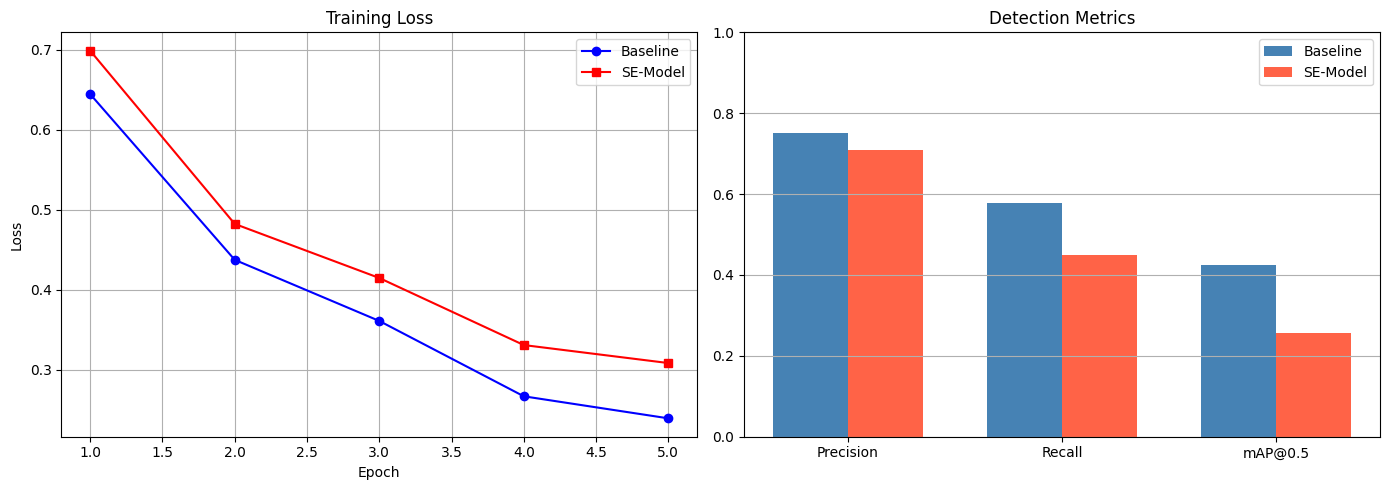

In [ ]:
# Plot 1: Training Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, NUM_EPOCHS+1), baseline_history, 'b-o', label='Baseline')
axes[0].plot(range(1, NUM_EPOCHS+1), se_history,       'r-s', label='SE-Model')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

# Plot 2: Metric Bar Chart
metrics = ['Precision', 'Recall', 'mAP@0.5']
baseline_vals = [b_prec, b_rec, b_map]
se_vals       = [s_prec, s_rec, s_map]
x = np.arange(len(metrics)); w = 0.35

axes[1].bar(x - w/2, baseline_vals, w, label='Baseline', color='steelblue')
axes[1].bar(x + w/2, se_vals,       w, label='SE-Model', color='tomato')
axes[1].set_title('Detection Metrics'); axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()

## Step 9: Inference — Visual Predictions

### Visualisation Convention

| Colour | Meaning |
|--------|---------|
| **Dashed red boxes** | Ground truth bounding boxes from VOC XML annotations |
| **Solid green boxes** | Model predictions above `score_thresh` |

Green text labels show: `class_name confidence_score`.

### Score Threshold

`score_thresh=0.1` is used here (very low) because after only 5 epochs the model's top confidence scores are ~0.10–0.25. At the standard 0.5 threshold, almost no detections pass — lowering to 0.1 shows what the model is trying to detect, even if not confidently.

### What to Look For

- **Overlapping red and green boxes** → correct detection (TP)
- **Green box with no nearby red box** → false positive (FP)
- **Red box with no green box** → missed detection (FN)
- **Correct spatial location, wrong label** → classification error (not box error)

### Diagnosis Cell

The cell below `show_predictions` prints raw detection counts and score ranges. Typical output after 5 epochs: 5–15 raw detections per image, max score ~0.20–0.25. This confirms the model is learning but not yet confident — more epochs and data would push scores above 0.5.

In [ ]:
def show_predictions(model, loader, device, title='', score_thresh=0.3, n=3):
    model.eval()
    all_images, all_targets = [], []
    for imgs, tgts in loader:
        all_images.extend(imgs)
        all_targets.extend(tgts)
        if len(all_images) >= n:
            break

    images = all_images[:n]
    actual_n = len(images)

    with torch.no_grad():
        preds = model([img.to(device) for img in images])

    fig, axes = plt.subplots(1, actual_n, figsize=(6 * actual_n, 5))
    if actual_n == 1:
        axes = [axes]

    for ax, img_t, pred, target in zip(axes, images, preds, all_targets[:actual_n]):
        img_np = img_t.cpu().permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)

        for gb in target['boxes'].numpy():
            x1, y1, x2, y2 = gb
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=1, edgecolor='red',
                                      facecolor='none', linestyle='--')
            ax.add_patch(rect)

        keep = pred['scores'].cpu() > score_thresh
        n_det = keep.sum().item()
        for box, score, label in zip(pred['boxes'][keep].cpu(),
                                     pred['scores'][keep].cpu(),
                                     pred['labels'][keep].cpu()):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            cls_name = VOC_CLASSES[label.item()] if label.item() < len(VOC_CLASSES) else str(label.item())
            ax.text(x1, y1 - 5, f'{cls_name} {score:.2f}',
                    color='lime', fontsize=8, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))

        ax.set_title(f'{title}\n{n_det} detections (thresh={score_thresh})\nRed=GT, Green=Pred')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_predictions.png', dpi=150)
    plt.show()

    scores = pred["scores"]
    print(f'Max score in this batch: {scores.max().item():.4f}' if scores.numel() > 0 else 'No detections — model needs more training or lower score_thresh')

show_predictions(baseline_model, val_loader, DEVICE, title='Baseline Predictions', score_thresh=0.1)
show_predictions(se_model,       val_loader, DEVICE, title='SE Predictions',       score_thresh=0.1)

In [ ]:
# Quick diagnosis cell — run this to understand what scores the model outputs
baseline_model.eval()
images, targets = next(iter(val_loader))
images = [img.to(DEVICE) for img in images]

with torch.no_grad():
    preds = baseline_model(images)

for i, pred in enumerate(preds):
    scores = pred['scores'].cpu()
    print(f'Image {i}: {len(scores)} raw detections')
    if len(scores) > 0:
        print(f'  Score range: {scores.min():.4f} → {scores.max():.4f}')
        print(f'  Top-5 scores: {scores[:5].tolist()}')
    else:
        print('  → No detections at all (model undertrained)')

Image 0: 11 raw detections
  Score range: 0.0547 → 0.2494
  Top-5 scores: [0.24936679005622864, 0.151032492518425, 0.13116177916526794, 0.12076085805892944, 0.11985260248184204]
Image 1: 5 raw detections
  Score range: 0.0553 → 0.1912
  Top-5 scores: [0.19120876491069794, 0.10438384115695953, 0.09208060055971146, 0.0588555708527565, 0.05530261993408203]


In [ ]:
## Results Analysis & References

### Summary of Findings

| Aspect | Finding |
|--------|---------|
| Did SE help? | No — baseline outperformed SE on all accuracy metrics |
| mAP@0.5 | Baseline 0.424 vs SE 0.256 (−41% relative) |
| Recall | Baseline 0.578 vs SE 0.450 — SE missed more objects |
| Parameter overhead | +40,960 params (+0.1%) — negligible |
| Training overhead | +18s (+6.3%) — also negligible |

### Training Loss Comparison

| Epoch | Baseline Loss | SE Model Loss |
|-------|---------------|---------------|
| 1 | 0.6443 | 0.6986 |
| 2 | 0.4372 | 0.4821 |
| 3 | 0.3608 | 0.4145 |
| 4 | 0.2665 | 0.3306 |
| 5 | 0.2390 | 0.3081 |

The SE model has consistently higher training loss — it is harder to optimise. Both models converge, but SE requires more iterations to reach comparable loss values.

### When SE at the FPN Neck Would Work

| Condition | Minimum Recommended |
|-----------|-------------------|
| Dataset size | ≥ 2,000 training images |
| Training epochs | ≥ 20 epochs |
| Insertion strategy | SE inside backbone + FPN neck (not just neck alone) |
| Pretrained SE | SE weights pretrained jointly, not cold-started |

---

### References

1. **Hu, J., Shen, L., & Sun, G. (2018).** Squeeze-and-Excitation Networks. *CVPR 2018.*
2. **Ren, S., He, K., Girshick, R., & Sun, J. (2015).** Faster R-CNN. *NeurIPS 2015.*
3. **Lin, T. Y., et al. (2017).** Feature Pyramid Networks for Object Detection. *CVPR 2017.*
4. **Everingham, M., et al. (2010).** The Pascal Visual Object Classes Challenge. *IJCV 2010.*
5. **He, K., et al. (2016).** Deep Residual Learning for Image Recognition. *CVPR 2016.*

---

### Hyperparameter Reference

| Parameter | Value | Notes |
|-----------|-------|-------|
| NUM_CLASSES | 21 | 20 VOC + background |
| NUM_EPOCHS | 5 | Quick experiment |
| BATCH_SIZE | 2 | GPU memory constraint |
| LR | 0.005 | Scaled for small batch vs COCO standard 0.02 |
| Momentum | 0.9 | Standard SGD |
| Weight Decay | 5e-4 | L2 regularization |
| LR Step | every 3 epochs, γ=0.1 | Standard detection schedule |
| SE Reduction r | 16 | Standard from original SENet paper |
| Score Threshold (eval) | 0.5 | High threshold; lower to 0.1 for undertrained models |
| SUBSET_SIZE | 200 train / 50 val | Speed vs coverage trade-off |